In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from metashapes.shape import Rectangle, Stripe
from metashapes.lattice.basis import Lattice
from metashapes.lattice.unit_cell import UnitCell
from metashapes.lattice.grid import cartesian_grid

dtype = torch.float32
device = 'cuda:0'

In [2]:
# Create lattice for visualisation
Lx = 1.0
Ly = 1.0
nx = 256
ny = 256

lattice = Lattice.rectangular(Lx, Ly)
lattice = lattice.to(dtype=dtype, device=device)

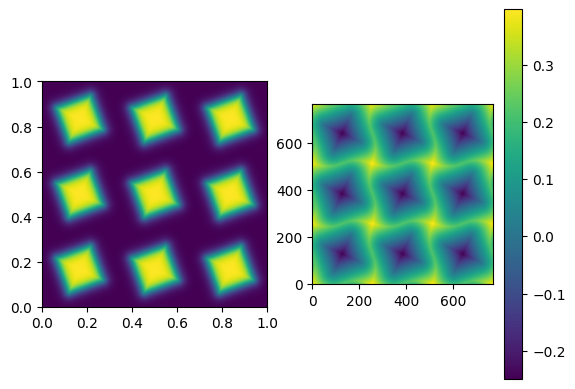

In [18]:
# Rectangle
center        = torch.nn.Parameter(torch.tensor([0.5, 0.5]))
size          = torch.nn.Parameter(torch.tensor([0.5, 0.5]))
angle         = torch.nn.Parameter(torch.tensor(20.0))
corner_radius = torch.tensor(0.02)

rect = Rectangle(center=center, size=size, angle=angle, corner_radius=corner_radius)
rect = rect.to(dtype=dtype, device=device)
rect_cell = UnitCell(lattice=lattice, scene=rect)

image = rect_cell.mask(nx, ny, repeat=(3, 3), cartesian=True, soft=True, softness=0.04)

sdf = rect_cell.rasterize(nx, ny, cartesian=True, repeat=(3, 3))

fc = torch.tensor([[0,0],[1,0],[0,1],[1,1]], dtype=lattice.dtype, device=lattice.device)
cx, cy = lattice.to_cartesian(fc[:,0], fc[:,1])
extent = [cx.min().item(), cx.max().item(), cy.min().item(), cy.max().item()]

plt.figure()
plt.subplot(121)
plt.imshow(image.cpu().detach(), aspect='equal', extent=extent, origin='lower')

plt.subplot(122)
plt.imshow(sdf.cpu().detach(), origin='lower')
plt.colorbar()

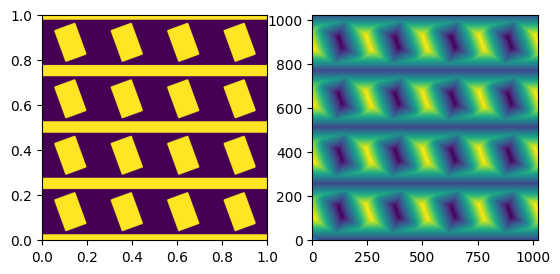

In [9]:
# Stripe
offset        = torch.nn.Parameter(torch.tensor(0.0))
width          = torch.nn.Parameter(torch.tensor(0.2))
axis         = 'x'

stripe = Stripe(offset, width, axis)
stripe = stripe.to(dtype=dtype, device=device)
stripe_cell = UnitCell(lattice=lattice, scene=(stripe.union(rect.rotate(-0, origin=(0.5, 0.5)))))

image = stripe_cell.mask(nx, ny, repeat=(4, 4), cartesian=True)

sdf = stripe_cell.rasterize(nx, ny, cartesian=True, repeat=(4, 4))

fc = torch.tensor([[0,0],[1,0],[0,1],[1,1]], dtype=lattice.dtype, device=lattice.device)
cx, cy = lattice.to_cartesian(fc[:,0], fc[:,1])
extent = [cx.min().item(), cx.max().item(), cy.min().item(), cy.max().item()]

plt.figure()
plt.subplot(121)
plt.imshow(image.cpu().detach(), aspect='equal', extent=extent, origin='lower')

plt.subplot(122)
plt.imshow(sdf.cpu().detach(), origin='lower')
plt.scatter(stripe_cell.boundary_points()[:,0], stripe_cell.boundary_points()[:,1], s = 10)

In [7]:
stripe_cell.boundary_points().shape

(2312, 2)

In [67]:
stripe_cell.scene.bounds()

((-inf, -0.20000000298023224), (inf, 0.9928363024895162))